In [284]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import corner

In [285]:
%matplotlib widget
plt.close('all')

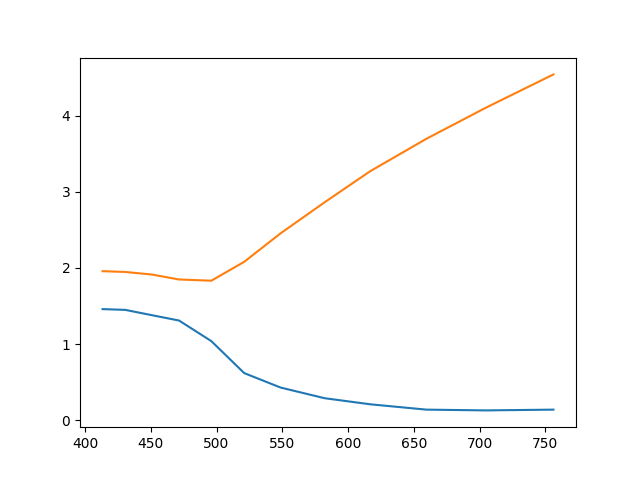

In [286]:
ns = np.loadtxt("temp/analisi/Au_n.txt")
ks = np.loadtxt("temp/analisi/Au_k.txt")
evs = np.loadtxt("temp/analisi/Au_evs.txt")
optical_consts_lambdas = 1240 / evs

min_lambda = 400
max_lambda = 800

lambda_mask = (optical_consts_lambdas >= min_lambda) & (optical_consts_lambdas <= max_lambda)

plt.plot(optical_consts_lambdas[lambda_mask], ns[lambda_mask], label="n")
plt.plot(optical_consts_lambdas[lambda_mask], ks[lambda_mask], label="k")

plt.show()


In [287]:

def sigma_ext(lam, n, k, V_np, n_m):
    return ((18 * np.pi * (n_m)**(3/2)) / (lam)) * V_np * (k / ((n+2*n_m)**2 + k**2))

def absorbance(l, rho, lam, n, k, V_np, n_m):
    sigma = sigma_ext(lam, n, k, V_np, n_m)
    return -np.log10(np.exp(-sigma * rho * l))

def log_likelihood(theta, lam, absorbance_data, n, k, n_m):
    V_np, rho, l, sigma = theta

    prediction = absorbance(l, rho, lam, n, k, V_np, n_m)
    
    gaussian = -0.5 * np.sum(np.log(((absorbance_data - prediction) / sigma) ** 2) + np.log(2 * np.pi * sigma ** 2))
    return gaussian

def log_prior(theta):
    V_np, rho, l, sigma = theta

    V_np_interval = (0, 1e-20)
    rho_interval = (0, 1e20)
    l_interval = (0, 2e-7)
    sigma_interval = (0, 10)

    if V_np_interval[0] < V_np < V_np_interval[1] and rho_interval[0] < rho < rho_interval[1] and l_interval[0] < l < l_interval[1] and sigma_interval[0] < sigma < sigma_interval[1]:
        return 0.0
    return -np.inf

def log_posterior(theta, lam, absorbance_data, n, k, n_m):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, lam, absorbance_data, n, k, n_m)




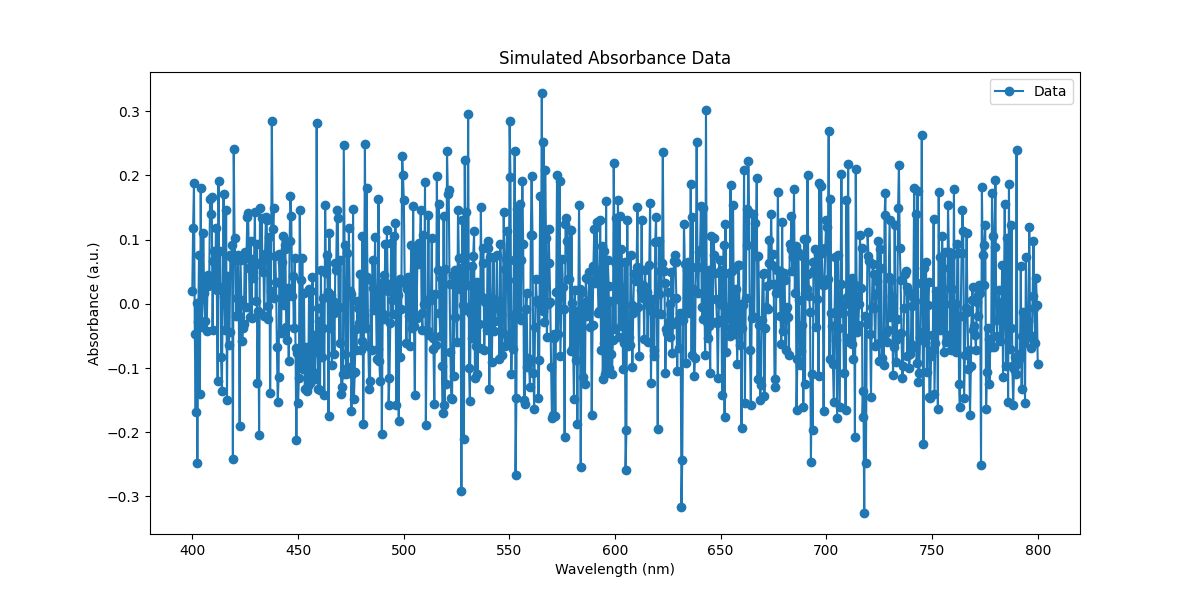

In [288]:
lmbdas = np.linspace(400, 800, 1000) * 1e-9
n_m = 1.33
V_np_true = 4/3 * np.pi * (5e-9)**3
rho_true = 1e18
l_true = 1e-7
sigma_true = 0.1

optical_consts_interp_n = np.interp(lmbdas, optical_consts_lambdas[lambda_mask], ns[lambda_mask]) * 1e-9
optical_consts_interp_k = np.interp(lmbdas, optical_consts_lambdas[lambda_mask], ks[lambda_mask]) * 1e-9
#print("optical_consts_lambdas: ", optical_consts_lambdas[lambda_mask])

absorbance_data = absorbance(l_true, rho_true, lmbdas, optical_consts_interp_n, optical_consts_interp_k, V_np_true, n_m) + np.random.normal(0, sigma_true, size=lmbdas.shape)
plt.figure(figsize=(12, 6))
plt.plot(lmbdas * 1e9, absorbance_data, label="Data", marker='o', linestyle='-')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance (a.u.)")
plt.title("Simulated Absorbance Data")
plt.legend()
plt.show()


lambdas:  [756.09756098 704.54545455 659.57446809 616.91542289 582.15962441
 548.67256637 521.00840336 496.         471.48288973 450.90909091
 430.55555556 413.33333333]
eps_m:  [15612.21798064-5.41143565e+11j 15616.01043564-5.04247413e+11j
 15619.17993564-4.72061408e+11j 15622.16626064-4.41530073e+11j
 15624.71547564-4.16655139e+11j 15626.98601964-3.92688251e+11j
 15628.88198364-3.72888843e+11j 15630.54985564-3.54990179e+11j
 15631.12544364-3.37443136e+11j 15631.06914864-3.22718344e+11j
 15631.13594064-3.08151197e+11j 15631.12598064-2.95825149e+11j]
eps_h:  (1+0j)


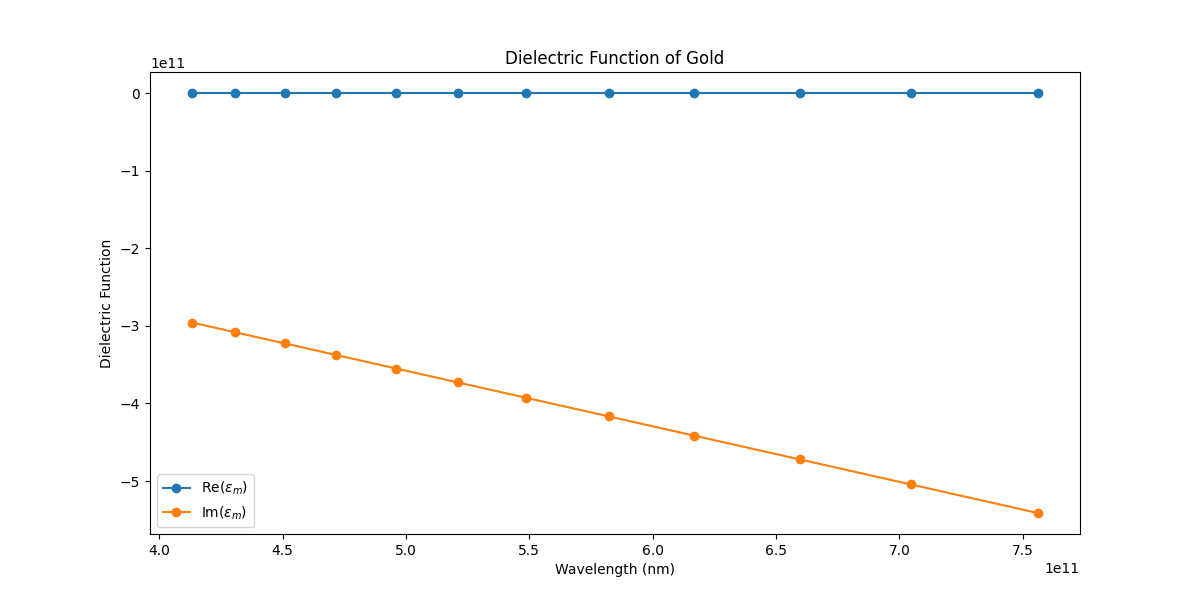

In [289]:
eps_m = (ns + 1j*ks)**2    # oro
eps_h = 1 + 0j    # aria
lambdas = optical_consts_lambdas[lambda_mask]

eps_m = eps_m[lambda_mask]

lam_nm = lambdas * 1e9     # nm
d_nm   = 8.0              # spessore in nm

E = 1240.0 / lam_nm                       # energia in eV
wp, g_bulk = 9.0, 0.07                    # eV, oro (plasma, damping bulk)
hbar_vF = 6.582e-16 * 1.4e6               # eV*m  (ħ * v_F dell'oro)
A_surf = 1.0                              # fattore superficiale, ~0.1-2
R = 4e-9                                  # raggio particella in m (~4 nm per cluster 8 nm)

g_size = g_bulk + A_surf * hbar_vF / R    # ~0.30 eV: quattro volte il bulk!
eps_m = eps_m + wp**2/(E**2 + 1j*g_bulk*E) - wp**2/(E**2 + 1j*g_size*E)

print("lambdas: ", lambdas)
print("eps_m: ", eps_m)
print("eps_h: ", eps_h)
    
plt.figure(figsize=(12, 6))
plt.plot(lam_nm, eps_m.real, label=r"Re($\epsilon_m$)", marker='o', linestyle='-')
plt.plot(lam_nm, eps_m.imag, label=r"Im($\epsilon_m$)", marker='o', linestyle='-')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Dielectric Function")
plt.title("Dielectric Function of Gold")
plt.legend()
plt.show()

In [290]:
# modelli

def eps_mg(eps_m, eps_h, f, L):
    """Maxwell-Garnett generalizzato (esplicito)."""
    return eps_h + (f*eps_h*(eps_m - eps_h)) / (eps_h + (1-f)*L*(eps_m - eps_h))

def eps_bruggeman(eps_m, eps_h, f, L):
    """Bruggeman generalizzato: quadratica + selezione radice passiva."""
    a = 1 - L
    b = -((f - L)*eps_m + (1 - L - f)*eps_h)
    c = -L*eps_m*eps_h
    disc = np.sqrt(b**2 - 4*a*c + 0j)
    r1 = (-b + disc)/(2*a)
    r2 = (-b - disc)/(2*a)
    return np.where(r1.imag >= 0, r1, r2)

def absorbance(eps_eff, lam, d, A0, A1, c_s, lam0=900.0):
    k_eff = np.sqrt(eps_eff).imag
    A_film = (4*np.pi*d)/(np.log(10)*lam) * k_eff
    return A_film + A0 + A1*(lam - lam0) + c_s*(lam0/lam)**4

In [291]:
# plot assorbanze

import ipywidgets as widgets

f_select = widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description='f:')
L_select = widgets.FloatSlider(value=1/3, min=0.01, max=1.0, step=0.01, description='L:')

with plt.ioff():
    
    fig = plt.figure(figsize=(12, 6))

    # artists
    mg_line_real, = plt.plot([], [], label=r"Re($\epsilon_{MG}$)", marker='o', linestyle='-')
    mg_line_imag, = plt.plot([], [], label=r"Im($\epsilon_{MG}$)", marker='o', linestyle='-')
    bruggeman_line_real, = plt.plot([], [], label=r"Re($\epsilon_{Bruggeman}$)", marker='o', linestyle='-')
    bruggeman_line_imag, = plt.plot([], [], label=r"Im($\epsilon_{Bruggeman}$)", marker='o', linestyle='-')

    # axes and labels
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Dielectric Function")
    plt.title("Effective Dielectric Functions")
    plt.legend()

    canvas = fig.canvas

def update_plot(f, L, relim=False):
    mg = eps_mg(eps_m, eps_h, f, L)
    bruggeman = eps_bruggeman(eps_m, eps_h, f, L)

    mg_absorbance = absorbance(mg, lambdas*1e9, d_nm*1e-9, A0=0.0, c_s=0.0, A1=1.0)
    bruggeman_absorbance = absorbance(bruggeman, lambdas*1e9, d_nm*1e-9, A0=0.0, c_s=0.0, A1=1.0)

    # update the data of the artists
    mg_line_real.set_data(lambdas, mg.real)
    mg_line_imag.set_data(lambdas, mg.imag)
    bruggeman_line_real.set_data(lambdas, bruggeman.real)
    bruggeman_line_imag.set_data(lambdas, bruggeman.imag)

    # update the limits of the axes
    if relim:
        plt.xlim(min_lambda, max_lambda)
        plt.ylim(min(eps_m.real.min(), eps_m.imag.min(), mg.real.min(), mg.imag.min(), bruggeman.real.min(), bruggeman.imag.min()),
                 max(eps_m.real.max(), eps_m.imag.max(), mg.real.max(), mg.imag.max(), bruggeman.real.max(), bruggeman.imag.max()))

    canvas.draw_idle()


f = 0.1
L = 1/3

mg = eps_mg(eps_m, eps_h, f, L)
bruggeman = eps_bruggeman(eps_m, eps_h, f, L)

update_plot(f, L, relim=True)

f_select.observe(lambda change: update_plot(change['new'], L_select.value), names='value')
L_select.observe(lambda change: update_plot(f_select.value, change['new']), names='value')

#timer = canvas.new_timer(interval=100)
#timer.add_callback(update_plot, f_select.value, L_select.value)
#timer.start()

display(widgets.VBox([f_select, L_select, canvas]))

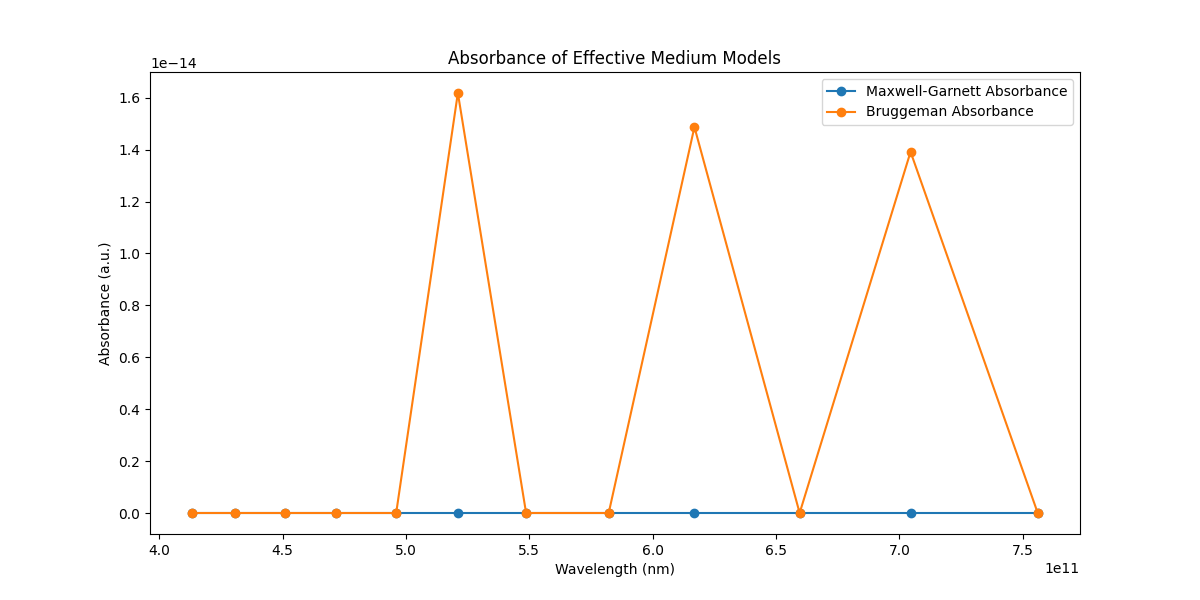

In [292]:
f = 0.2
L = 1/3
A1 = 10e-40

mg = eps_mg(eps_m, eps_h, f, L)
bruggeman = eps_bruggeman(eps_m, eps_h, f, L)

mg_absorbance = absorbance(mg, lambdas*1e9, d_nm*1e-9, A0=0.0, c_s=0.0, A1=A1)
bruggeman_absorbance = absorbance(bruggeman, lambdas*1e9, d_nm*1e-9, A0=0.0, c_s=0.0, A1=A1)

plt.figure(figsize=(12, 6))
plt.plot(lambdas*1e9, mg_absorbance, label="Maxwell-Garnett Absorbance", marker='o', linestyle='-')
plt.plot(lambdas*1e9, bruggeman_absorbance, label="Bruggeman Absorbance", marker='o', linestyle='-')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance (a.u.)")
plt.title("Absorbance of Effective Medium Models")
plt.legend()
plt.show()

In [293]:
from dataclasses import dataclass
from typing import Callable

def make_transform(specs):
    # specs: lista di (kind, a, b); kind in {"uniform", "loguniform"}
    def transform(cube):
        theta = np.empty_like(cube)
        for i, (kind, a, b) in enumerate(specs):
            u = cube[i]
            theta[i] = a + (b - a)*u if kind == "uniform" else a*(b/a)**u
        return theta
    return transform

@dataclass
class Model:
    name: str
    param_names: list
    prior_transform: Callable
    eps_eff: Callable          # (eps_m, eps_h, p_dict) -> eps_eff

# wrapper che pescano i parametri dal dict (L assente nel Bruggeman semplice)
def _mg(eps_m, eps_h, p):       return eps_mg(eps_m, eps_h, p["f"], p["L"])
def _brg_gen(eps_m, eps_h, p):  return eps_bruggeman(eps_m, eps_h, p["f"], p["L"])
def _brg_simple(eps_m, eps_h, p): return eps_bruggeman(eps_m, eps_h, p["f"], 1/3)

# nuisance comuni a TUTTI: A0, c_s, sigma (l'ordine deve combaciare con param_names)
common_specs = [("uniform", -0.3, 0.3),   # A0  (può essere negativo)
                ("uniform",  0.0,  0.20),    # c_s
                ("loguniform", 1e-4, 1e-1),
                ("uniform", -0.1, 0.1)]  # A1
common_names = ["A0", "c_s", "sigma", "A1"]

brg_simple = Model("BruggemanSimple",
    ["f"] + common_names,
    make_transform([("uniform", 0.01, 0.7)] + common_specs),
    _brg_simple)

brg_gen = Model("BruggemanGen",
    ["f", "L"] + common_names,
    make_transform([("uniform", 0.01, 0.7), ("uniform", 0.02, 0.9)] + common_specs),
    _brg_gen)

mg = Model("MaxwellGarnett",
    ["f", "L"] + common_names,
    make_transform([("uniform", 0.01, 0.7), ("uniform", 0.02, 0.9)] + common_specs),
    _mg)

In [294]:
# Likelyhood

def make_loglike(model, lam, A_obs, eps_m, eps_h, d):
    def loglike(theta):
        p = dict(zip(model.param_names, theta))
        sigma = p["sigma"]
        eps_eff = model.eps_eff(eps_m, eps_h, p)
        A_pred  = absorbance(eps_eff, lam, d, p["A0"], p["A1"], p["c_s"])
        if not np.all(np.isfinite(A_pred)):
            return -1e100
        r = (A_obs - A_pred)/sigma
        return -0.5*np.sum(r**2 + np.log(2*np.pi*sigma**2))
    return loglike


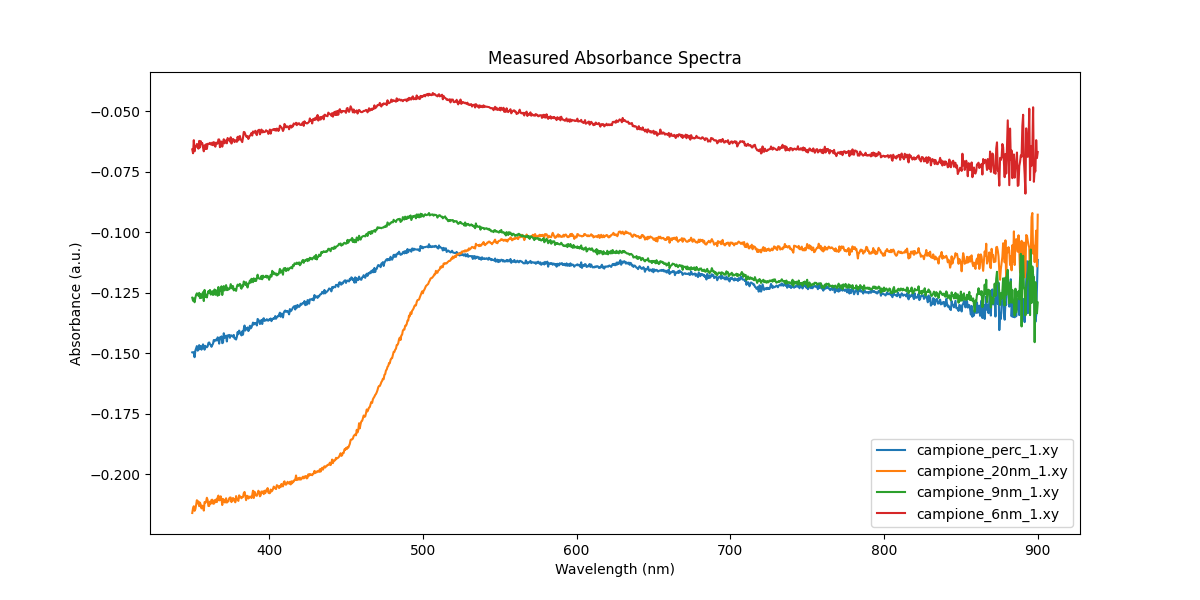

In [295]:
# caricamento dati
import os

spettri_dir = "data/spettri/"

available_spectra = [i for i in os.listdir(spettri_dir) if i.endswith(".xy") and "reference" not in i]

reference_spectrum = np.loadtxt(os.path.join(spettri_dir, "reference2.xy"))

available_spectra = [i for i in available_spectra if "pt" not in i]

spectra = [np.loadtxt(os.path.join(spettri_dir, spec)) for spec in available_spectra]
#spectra = [spec - reference_spectrum for spec in spectra]

lambdas_exp = spectra[0][:, 0]

for spec in spectra:
    spec[:, 1] = spec[:, 1] - reference_spectrum[:, 1]

plt.figure(figsize=(12, 6))
for spec, name in zip(spectra, available_spectra):

    x = spec[:, 0]
    y = spec[:, 1]

    plt.plot(x, y, label=name)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance (a.u.)")
plt.title("Measured Absorbance Spectra")
plt.legend()
plt.show()


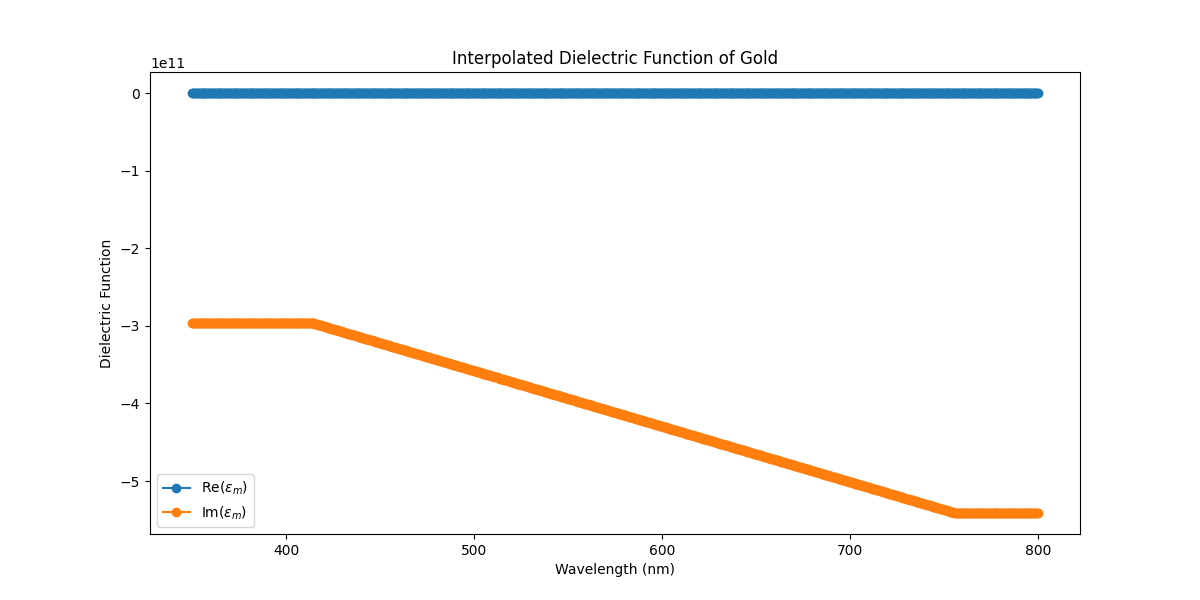

In [ ]:
# interpolazione epsilon_m sulle lambdas dei dati sperimentali

min_lambda = 400
max_lambda = 800

exp_mask = (lambdas_exp >= min_lambda) & (lambdas_exp <= max_lambda)
lambdas_exp = lambdas_exp[exp_mask]

sorted_indices = np.argsort(lambdas)
lambdas = lambdas[sorted_indices]
eps_m = eps_m[sorted_indices]
eps_m_interp = np.interp(lambdas_exp, lambdas, eps_m)


plt.figure(figsize=(12, 6))

plt.plot(lambdas_exp, eps_m_interp.real, label=r"Re($\epsilon_m$)", marker='o', linestyle='-')
plt.plot(lambdas_exp, eps_m_interp.imag, label=r"Im($\epsilon_m$)", marker='o', linestyle='-')
plt.xlabel("Wavelength (nm)")
plt.ylabel("Dielectric Function")
plt.title("Interpolated Dielectric Function of Gold")
plt.legend()
plt.show()

In [297]:
import ultranest

def run_model(model, lam, A_obs, eps_m, eps_h, d, live=400):
    loglike = make_loglike(model, lam, A_obs, eps_m, eps_h, d)
    sampler = ultranest.ReactiveNestedSampler(
        model.param_names, loglike, model.prior_transform)
    return sampler.run(min_num_live_points=live, show_status=True)

spettro = spectra[3][:, 1]
spettro = spettro[exp_mask]

results = {m.name: run_model(m, lambdas_exp, spettro, eps_m_interp, eps_h, d_nm)
           for m in [brg_simple, brg_gen, mg]}

for name, r in results.items():
    print(f"{name:18s}  logZ = {r['logz']:.2f} ± {r['logzerr']:.2f}")

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=3e+03  7.51 [3294.8095..3294.8101]*| it/evals=13860/392526 eff=3.5346% N=400    0  0  0  00  0  
[ultranest] Likelihood function evaluations: 392526
[ultranest]   logZ = 3262 +- 0.2218
[ultranest] Effective samples strategy satisfied (ESS = 494.0, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.55, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.22 tail:0.51 total:0.55 required:<0.50
[ultranest] done iterating.
[ultranest] Sampling 400 live points from prior ...


/home/luca/Desktop/Code/lab_materia_2/.venv/lib/python3.13/site-packages/ultranest/integrator.py:1903: UserWarning: Sampling from region seems inefficient (0/40 accepted in iteration 2500). To improve efficiency, modify the transformation so that the current live points are ellipsoidal, or use a stepsampler, or set frac_remain to a lower number (e.g., 0.5) to terminate earlier.
  u, v, logl, nc, quality = self._refill_samples(Lmin, ndraw, nit)


[ultranest] Explored until L=3e+03  7.56 [3294.9064..3294.9072]*| it/evals=13680/899496 eff=1.5215% N=400 
[ultranest] Likelihood function evaluations: 899496
[ultranest]   logZ = 3262 +- 0.202
[ultranest] Effective samples strategy satisfied (ESS = 569.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.54, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.20 tail:0.50 total:0.54 required:<0.50
[ultranest] done iterating.
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=3e+03  7.35 [3294.7055..3294.7073]*| it/evals=13200/61141 eff=21.7316% N=400    0   0  0  00 
[ultranest] Likelihood function evaluations: 61327
[ultranest]   logZ = 3263 +- 0.178
[ultranest] Effective samples strategy satisfied (ESS = 546.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.53, need <0.5)
[ultranest]   logZ error budget: single: 0.28 bs:0.18 tail:0.50 total:0.53 required:<0.50
[ultranest] done iterating.
BruggemanSimple     logZ = 3261.62 ± 0.66
BruggemanGen        logZ = 3262.14 ± 0.61
MaxwellGarnett      logZ = 3263.16 ± 0.64


In [298]:
def predict(model, theta, eps_m, eps_h, lam, d):
    p = dict(zip(model.param_names, theta))
    eps_eff = model.eps_eff(eps_m, eps_h, p)
    return absorbance(eps_eff, lam, d, p["A0"], p["A1"], p["c_s"])

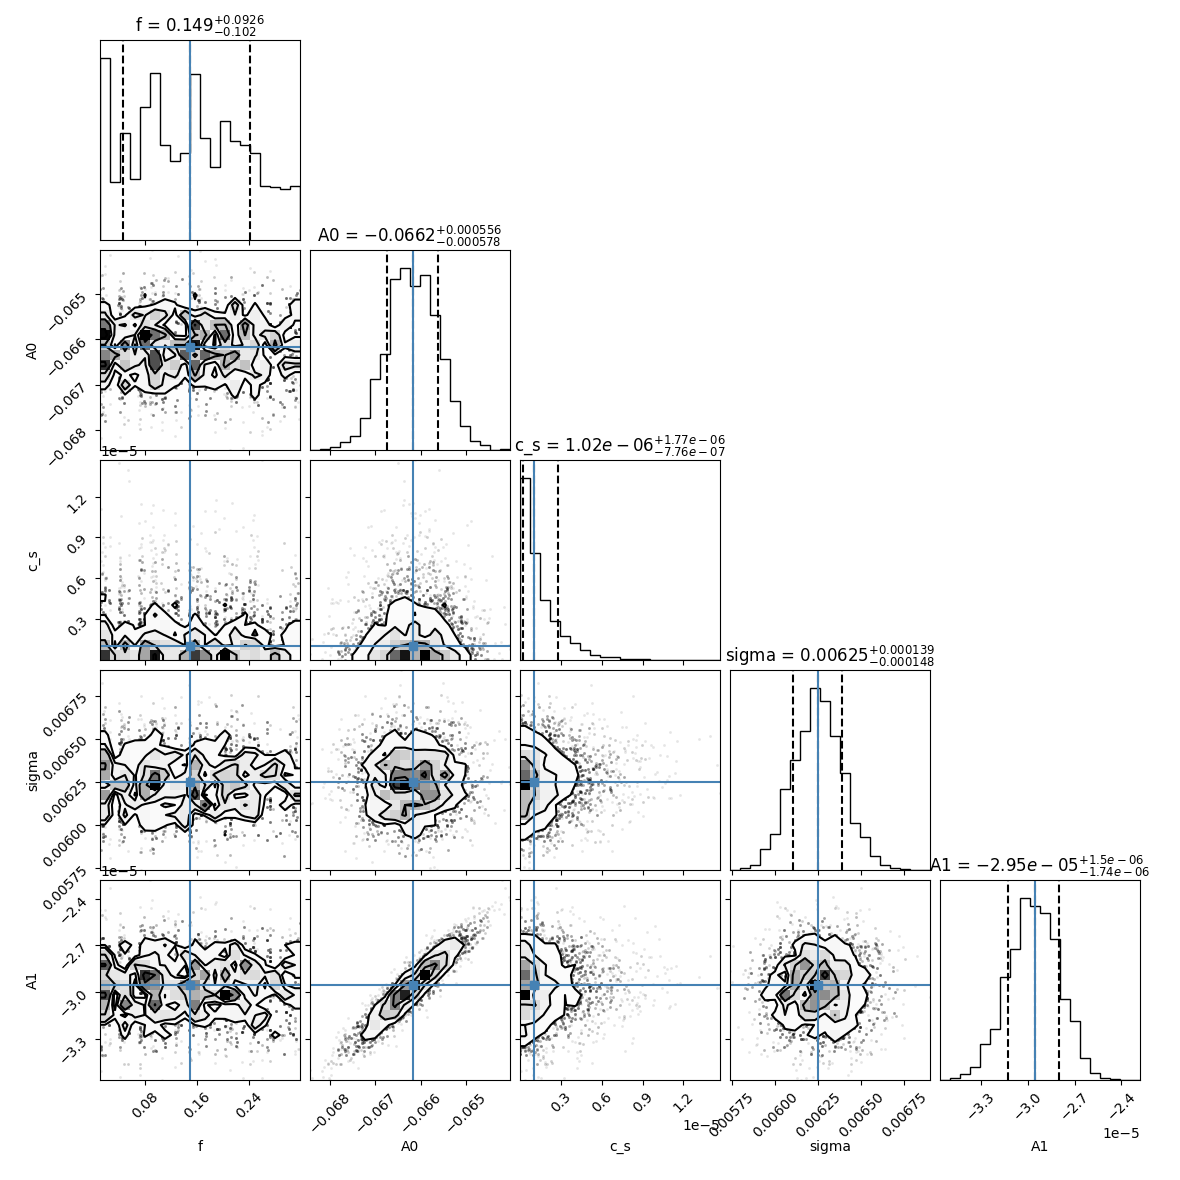

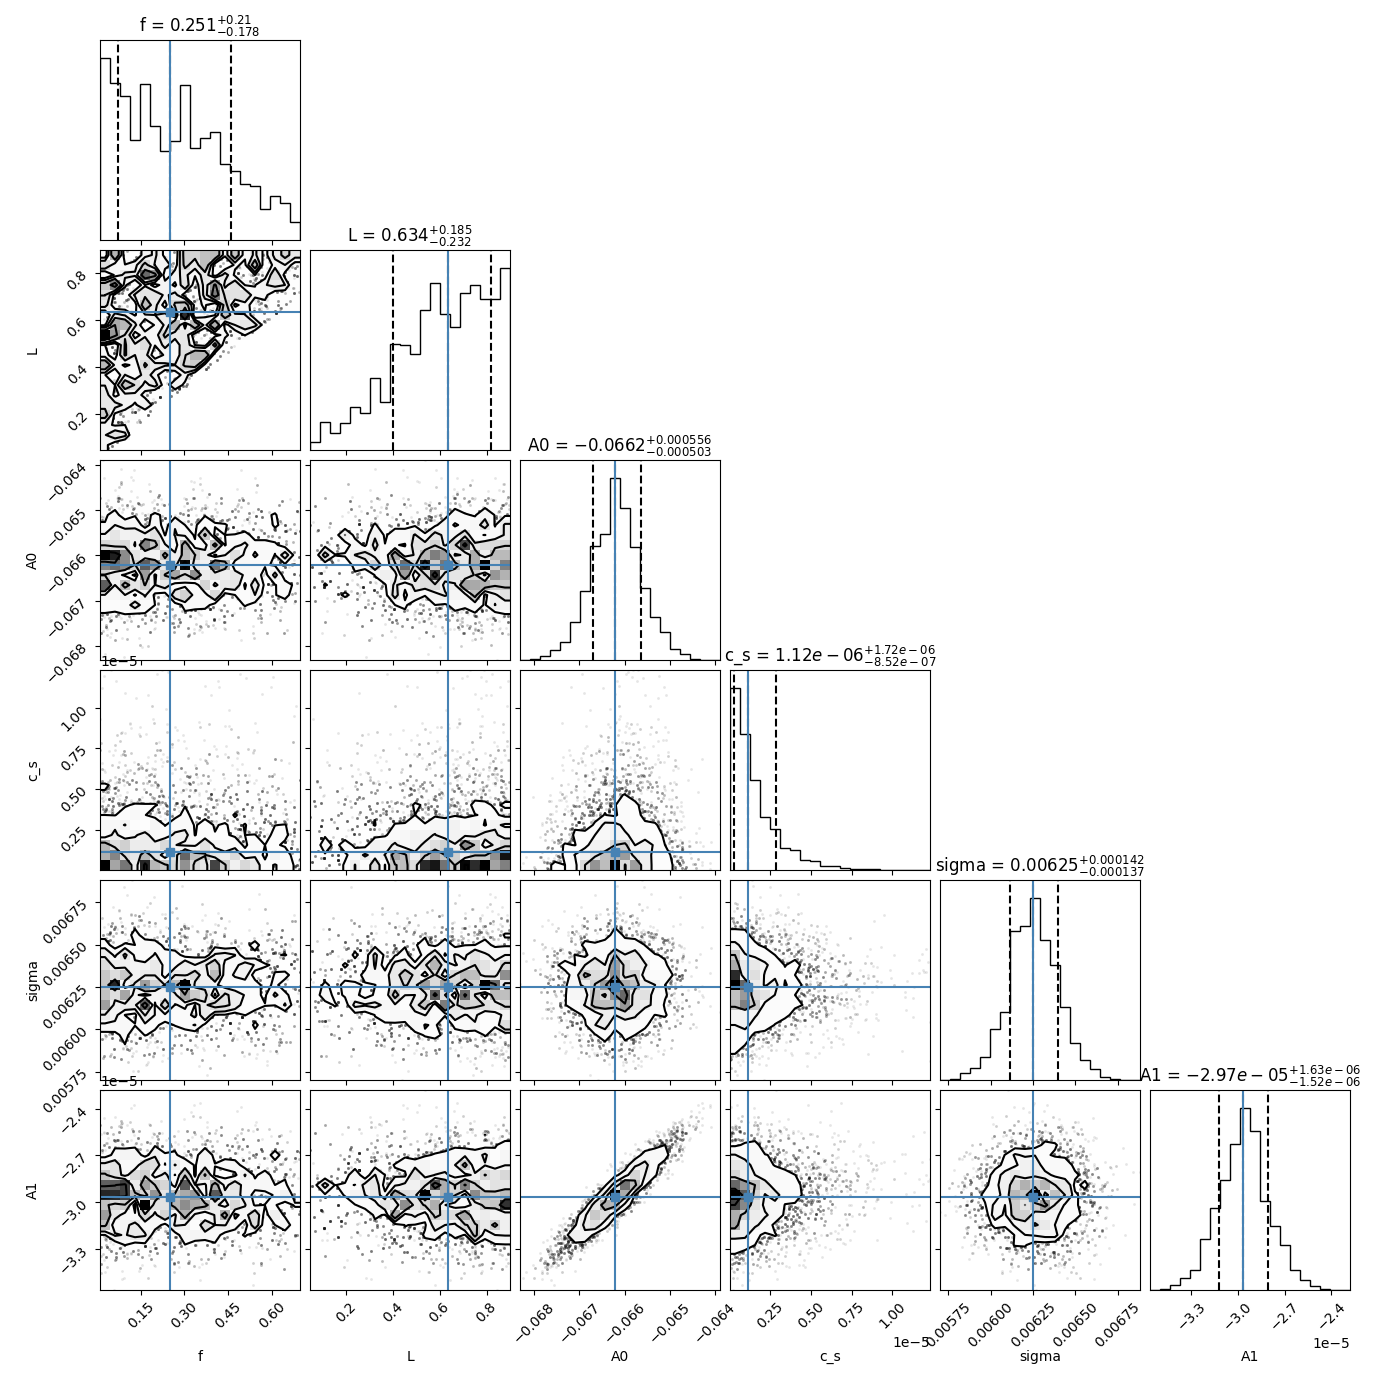

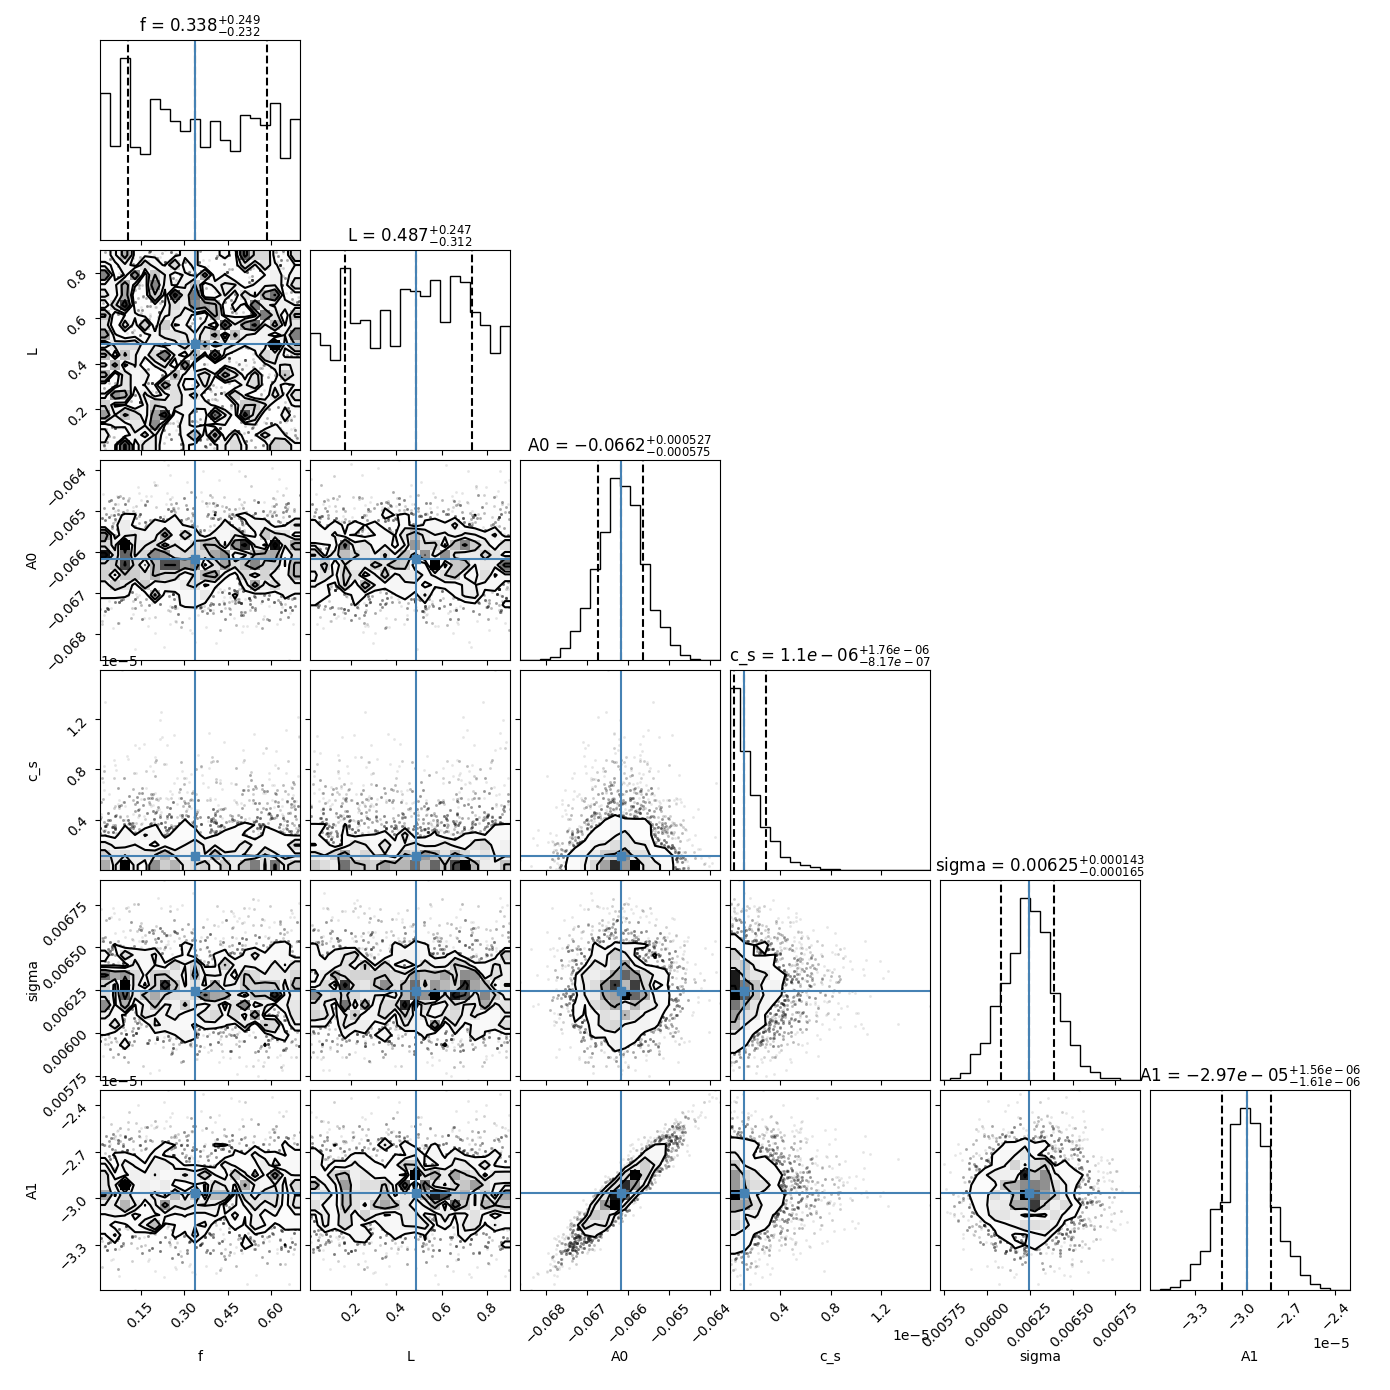

In [299]:
import corner

def plot_corner(model, result):
    samples = result["samples"]              # campioni a peso uniforme
    med = np.median(samples, axis=0)
    fig = corner.corner(
        samples, labels=model.param_names, truths=med,
        show_titles=True, quantiles=[0.16, 0.5, 0.84], title_fmt=".3g")
    fig.suptitle(model.name, y=1.02)
    return fig

for m in [brg_simple, brg_gen, mg]:
    plot_corner(m, results[m.name])

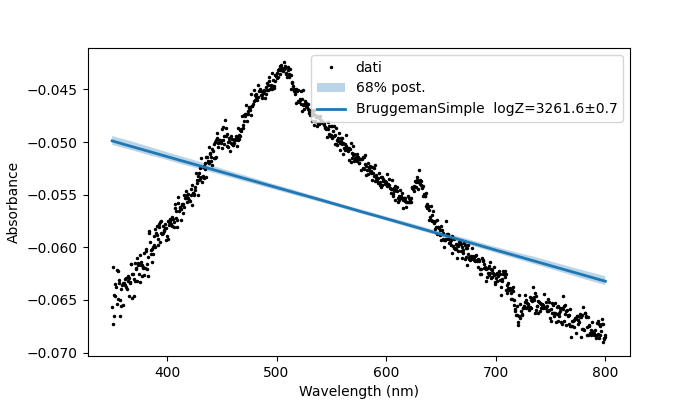

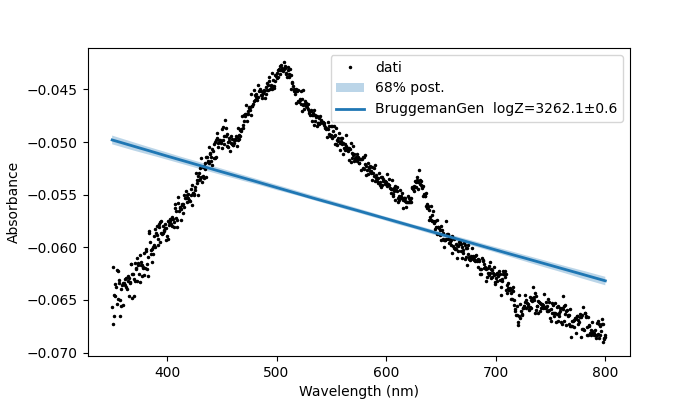

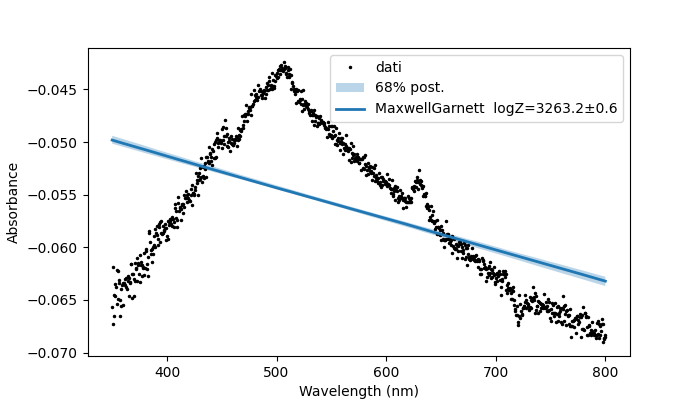

In [300]:
def post_predictive(model, samples, eps_m, eps_h, lam, d, n=200):
    idx = np.random.choice(len(samples), min(n, len(samples)), replace=False)
    preds = np.array([predict(model, samples[i], eps_m, eps_h, lam, d) for i in idx])
    lo, med, hi = np.percentile(preds, [16, 50, 84], axis=0)
    return lo, med, hi

def plot_fit(model, result, lam, A_obs, eps_m, eps_h, d, ax=None):
    lo, med, hi = post_predictive(model, result["samples"], eps_m, eps_h, lam, d)
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ax.plot(lam, A_obs, "k.", ms=3, label="dati")
    ax.fill_between(lam, lo, hi, alpha=0.3, label="68% post.")
    ax.plot(lam, med, lw=2,
            label=f"{model.name}  logZ={result['logz']:.1f}±{result['logzerr']:.1f}")
    ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Absorbance"); ax.legend()
    return ax

for m in [brg_simple, brg_gen, mg]:
    plot_fit(m, results[m.name], lambdas_exp, spettro, eps_m_interp, eps_h, d_nm)

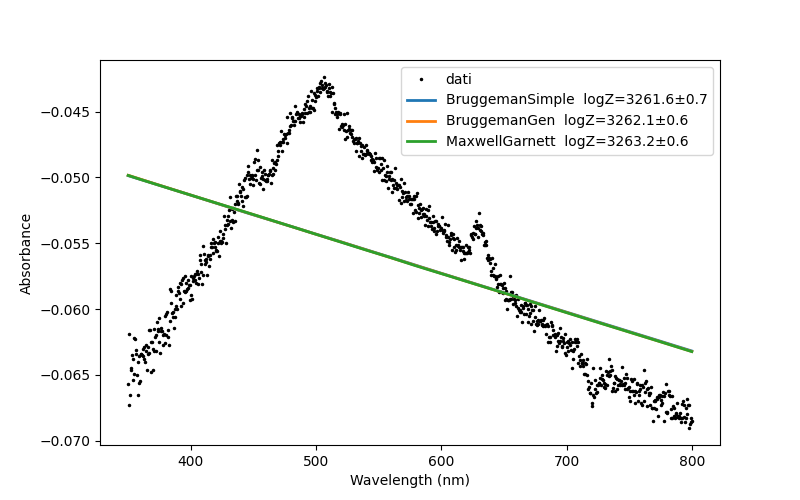

In [301]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(lambdas_exp, spettro, "k.", ms=3, label="dati")
for m in [brg_simple, brg_gen, mg]:
    r = results[m.name]
    _, med, _ = post_predictive(m, r["samples"], eps_m_interp, eps_h, lambdas_exp, d_nm)
    ax.plot(lambdas_exp, med, lw=2,
            label=f"{m.name}  logZ={r['logz']:.1f}±{r['logzerr']:.1f}")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Absorbance"); ax.legend()